# **Heart disease**

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.model_selection import train_test_split

In [55]:
df = pd.read_csv('https://raw.githubusercontent.com/ChickenMan-1080/ML-Practice/refs/heads/main/ML-Heart/assets/heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [57]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [58]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [59]:
df['Age'].median()

np.float64(54.0)

# EDA

<Axes: ylabel='count'>

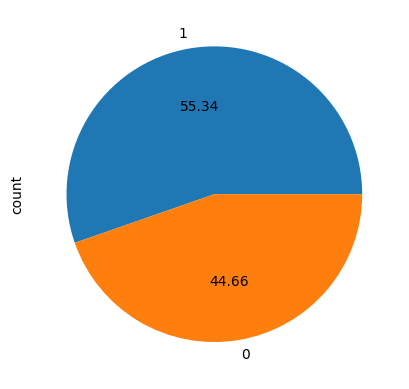

In [60]:
#target
df['HeartDisease'].value_counts().plot.pie(autopct='%.2f')

<Axes: xlabel='Age', ylabel='Count'>

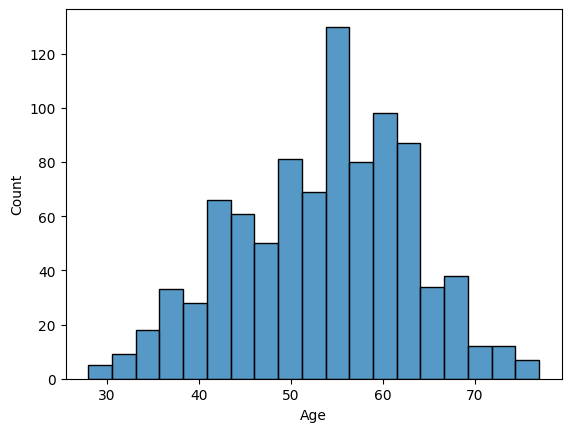

In [61]:
#Age
sns.histplot(df,x='Age')

C:\Users\natth\AppData\Local\Temp\ipykernel_9572\2412603038.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df,x='Sex',palette='Spectral')


<Axes: xlabel='Sex', ylabel='count'>

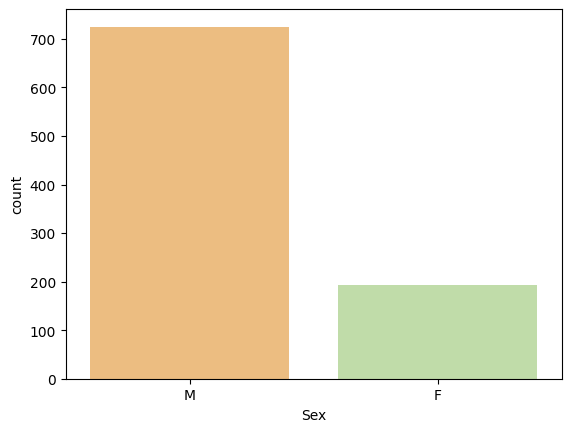

In [62]:
sns.countplot(df,x='Sex',palette='Spectral')

C:\Users\natth\AppData\Local\Temp\ipykernel_9572\1128492245.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df,x='ChestPainType',palette='Spectral')


<Axes: xlabel='ChestPainType', ylabel='count'>

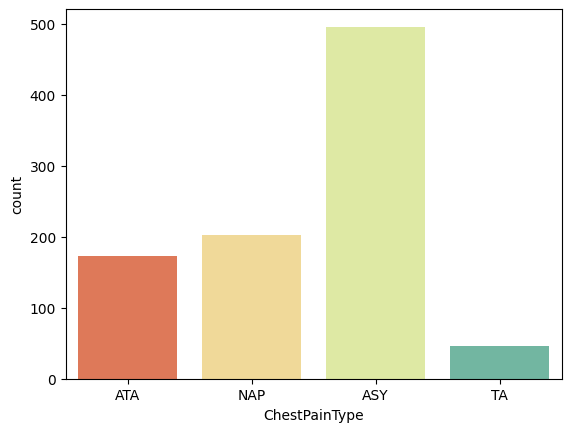

In [63]:
sns.countplot(df,x='ChestPainType',palette='Spectral')

<Axes: xlabel='RestingBP'>

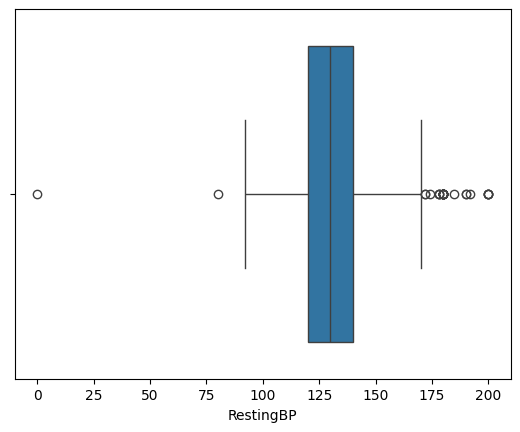

In [64]:
sns.boxplot(df,x='RestingBP')

### Clean RestingBP

<Axes: xlabel='RestingBP'>

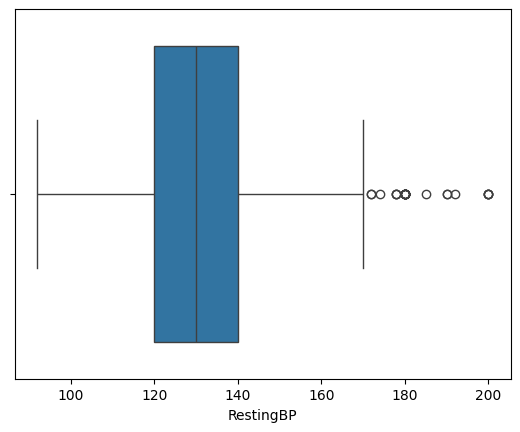

In [65]:
Q1_RestingBP = df['RestingBP'].quantile(0.25)
Q3_RestingBP = df['RestingBP'].quantile(0.75)
IQR_RestingBP = Q3_RestingBP - Q1_RestingBP

df_drop_outliers = df[df['RestingBP'] >= Q1_RestingBP - (1.5 * IQR_RestingBP)]
sns.boxplot(df_drop_outliers,x='RestingBP')

In [66]:
print(df_drop_outliers[df_drop_outliers['RestingBP'] > Q3_RestingBP + (1.5*IQR_RestingBP)].shape)
df_drop_outliers[df_drop_outliers['RestingBP'] > Q3_RestingBP + (1.5*IQR_RestingBP)].head()

(26, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
109,39,M,ATA,190,241,0,Normal,106,N,0.0,Up,0
123,58,F,ATA,180,393,0,Normal,110,Y,1.0,Flat,1
189,53,M,ASY,180,285,0,ST,120,Y,1.5,Flat,1
190,46,M,ASY,180,280,0,ST,120,N,0.0,Up,0
241,54,M,ASY,200,198,0,Normal,142,Y,2.0,Flat,1


In [67]:
#เช็คผลต่าง HeartDisease 0 และ 1
df_drop_outliers[(df_drop_outliers['RestingBP'] >= 180) & (df_drop_outliers['Cholesterol'] != 0)]['HeartDisease'].value_counts()

HeartDisease
1    9
0    6
Name: count, dtype: int64

#### แยกเคสโรค

<Axes: xlabel='RestingBP'>

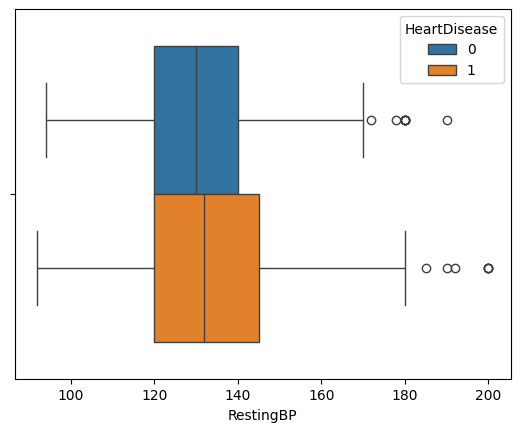

In [68]:
sns.boxplot(df_drop_outliers,x='RestingBP',hue='HeartDisease')

##### Boxplot for non HeartDisease

In [69]:
Q1_RestingBP_0 = df_drop_outliers[df_drop_outliers['HeartDisease'] == 0]['RestingBP'].quantile(0.25)
Q3_RestingBP_0 = df_drop_outliers[df_drop_outliers['HeartDisease'] == 0]['RestingBP'].quantile(0.25)
IQR_RestingBP_0 = Q3_RestingBP_0 - Q1_RestingBP_0

C:\Users\natth\AppData\Local\Temp\ipykernel_9572\1622846290.py:1: FutureWarning: Operation between Series with different indexes that are not of numpy boolean or object dtype will no longer return a numpy boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  sns.boxplot(df_drop_outliers[(df_drop_outliers['RestingBP']) & (df['HeartDisease']==0)],x='RestingBP',hue='HeartDisease')
C:\Users\natth\AppData\Local\Temp\ipykernel_9572\1622846290.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.boxplot(df_drop_outliers[(df_drop_outliers['RestingBP']) & (df['HeartDisease']==0)],x='RestingBP',hue='HeartDisease')


<Axes: xlabel='RestingBP'>

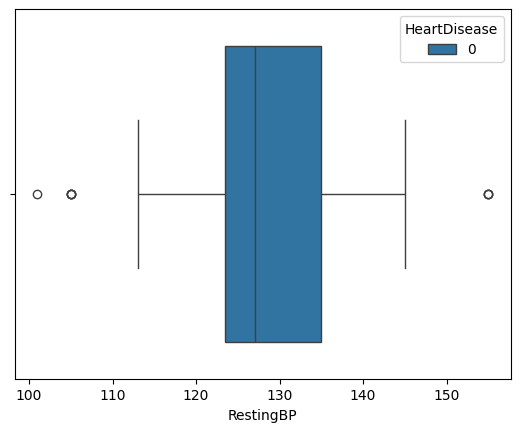

In [70]:
sns.boxplot(df_drop_outliers[(df_drop_outliers['RestingBP']) & (df['HeartDisease']==0)],x='RestingBP',hue='HeartDisease')

In [ ]:
'''df_RestingBP_0_outlier_minus = df_drop_outliers[(df_drop_outliers['RestingBP'] < Q1_RestingBP_0 - (1.5*IQR_RestingBP_0)) & (df_drop_outliers['HeartDisease']==0)]
df_RestingBP_0_outlier_minus['HeartDisease'].value_counts()''' #มั่วทำอะไรไม่รู้อย่าสนลบเลยก็ได้

HeartDisease
0    72
Name: count, dtype: int64

<Axes: xlabel='RestingBP'>

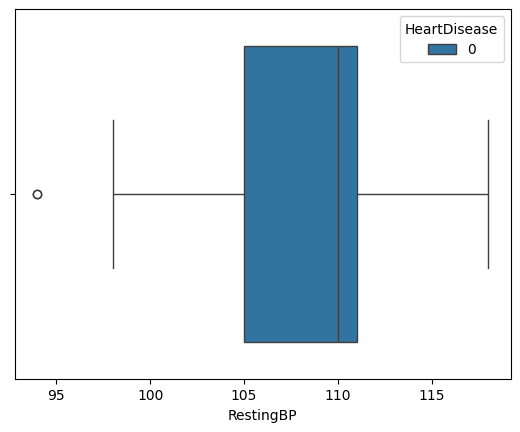

In [ ]:
sns.boxplot(df_RestingBP_0_outlier_minus,x='RestingBP',hue='HeartDisease')

## รอปรับ outlier ของ RestingBP

#### Cholesterol

<Axes: xlabel='Cholesterol'>

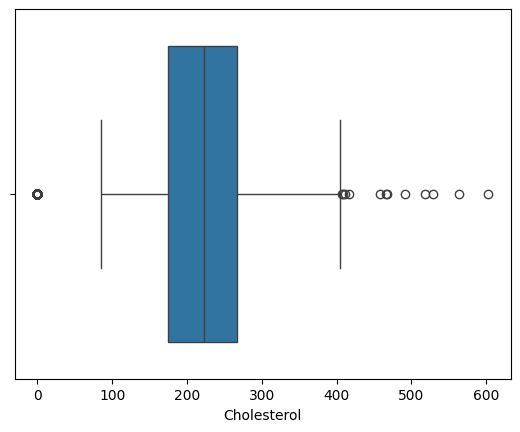

In [ ]:
sns.boxplot(df_drop_outliers,x='Cholesterol')

In [ ]:
df_drop_outliers = df_drop_outliers[df_drop_outliers['Cholesterol']  >= 120]
df_drop_outliers.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
mean,52.841892,133.133784,245.774324,0.167568,140.335135,0.896757,0.475676
std,9.470594,17.236544,58.009743,0.373734,24.572691,1.069855,0.499746
min,28.000000,94.000000,123.000000,0.000000,69.000000,-0.100000,0.000000
25%,46.000000,120.000000,208.000000,0.000000,122.000000,0.000000,0.000000
50%,54.000000,130.000000,238.000000,0.000000,140.000000,0.500000,0.000000
75%,59.000000,140.000000,275.250000,0.000000,160.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


<Axes: xlabel='Cholesterol'>

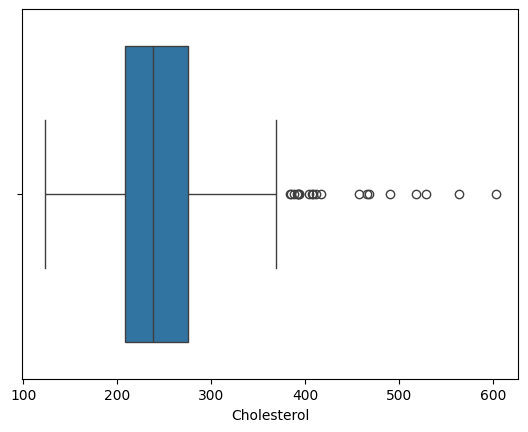

In [ ]:
sns.boxplot(df_drop_outliers,x='Cholesterol')

In [ ]:
Q1_Cholesterol = df_drop_outliers['Cholesterol'].quantile(0.25)
Q3_Cholesterol = df_drop_outliers['Cholesterol'].quantile(0.75)
IQR_Cholesterol = Q3_Cholesterol - Q1_Cholesterol

df_drop_outliers[df_drop_outliers['Cholesterol'] > Q3_Cholesterol + (1.5 * IQR_Cholesterol)]['HeartDisease'].value_counts()

HeartDisease
1    12
0     8
Name: count, dtype: int64

In [ ]:
df_drop_outliers[(df_drop_outliers['Cholesterol'] > Q3_Cholesterol + (1.5 * IQR_Cholesterol)) & (df_drop_outliers['Cholesterol'] < 450)].describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,56.333333,148.666667,398.250000,0.250000,140.750000,1.266667,0.583333
std,8.037790,14.877276,11.087462,0.452267,18.020821,1.188072,0.514929
min,40.000000,130.000000,384.000000,0.000000,110.000000,0.000000,0.000000
25%,54.250000,140.000000,391.000000,0.000000,128.500000,0.225000,0.000000
50%,57.000000,145.000000,394.000000,0.000000,142.500000,1.100000,1.000000
75%,62.250000,152.500000,407.500000,0.250000,154.750000,2.000000,1.000000
max,67.000000,180.000000,417.000000,1.000000,170.000000,4.000000,1.000000


<Axes: xlabel='Cholesterol'>

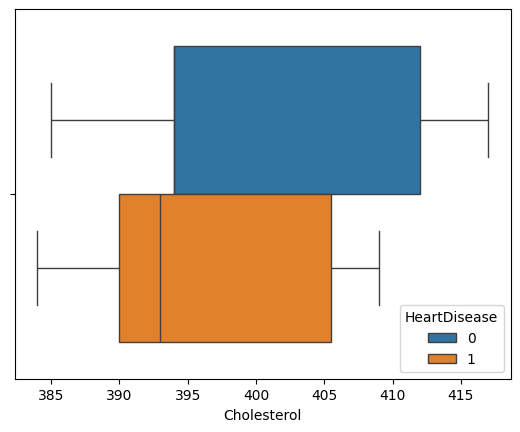

In [ ]:
sns.boxplot(df_drop_outliers[(df_drop_outliers['Cholesterol'] > Q3_Cholesterol + (1.5 * IQR_Cholesterol)) & (df_drop_outliers['Cholesterol'] < 450)],x='Cholesterol',hue='HeartDisease')

In [ ]:
df_drop_outliers[(df_drop_outliers['Cholesterol'] < 450) & (df_drop_outliers['HeartDisease'] == 1)].max()

Age                77
Sex                 M
ChestPainType      TA
RestingBP         200
Cholesterol       409
FastingBS           1
RestingECG         ST
MaxHR             195
ExerciseAngina      Y
Oldpeak           6.2
ST_Slope           Up
HeartDisease        1
dtype: object

In [ ]:
df_drop_outliers = df_drop_outliers[df_drop_outliers['Cholesterol'] <= 409]
df_drop_outliers.max()

Age                77
Sex                 M
ChestPainType      TA
RestingBP         200
Cholesterol       409
FastingBS           1
RestingECG         ST
MaxHR             202
ExerciseAngina      Y
Oldpeak           6.2
ST_Slope           Up
HeartDisease        1
dtype: object

<Axes: xlabel='Cholesterol'>

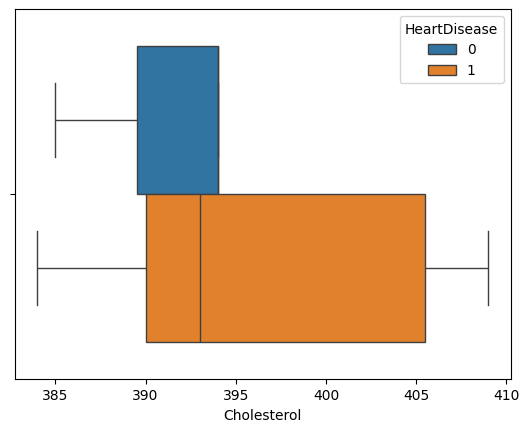

In [ ]:
sns.boxplot(df_drop_outliers[(df_drop_outliers['Cholesterol'] > Q3_Cholesterol + (1.5 * IQR_Cholesterol)) & (df_drop_outliers['Cholesterol'] < 450)],x='Cholesterol',hue='HeartDisease')

<Axes: xlabel='Cholesterol'>

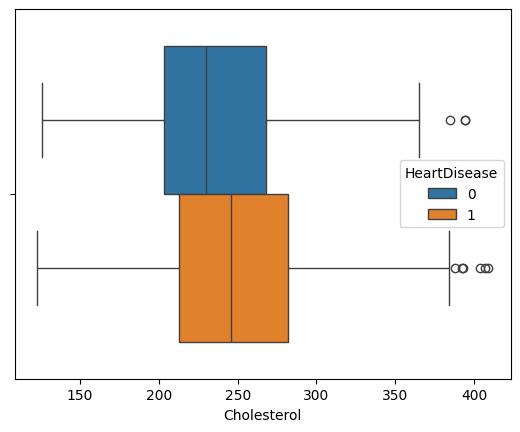

In [ ]:
sns.boxplot(df_drop_outliers,x='Cholesterol',hue='HeartDisease')

## MaxHR

<Axes: xlabel='MaxHR'>

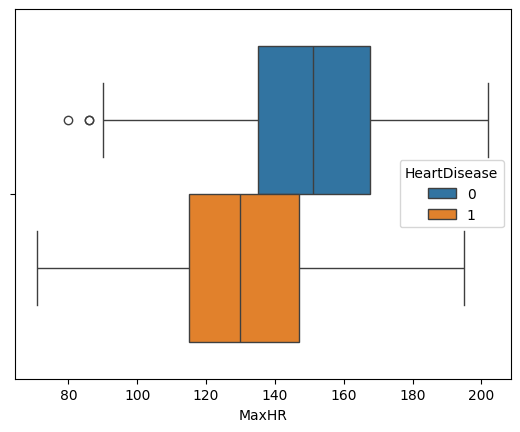

In [ ]:
sns.boxplot(df_drop_outliers,x='MaxHR',hue='HeartDisease')

In [ ]:
Q1_MaxHR = df_drop_outliers['MaxHR'].quantile(0.25)
Q3_MaxHR = df_drop_outliers['MaxHR'].quantile(0.75)
IQR_MaxHR = Q3_MaxHR - Q1_MaxHR

In [ ]:
df_drop_outliers[df_drop_outliers['MaxHR'] < Q1_MaxHR - (1.5 * IQR_MaxHR)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


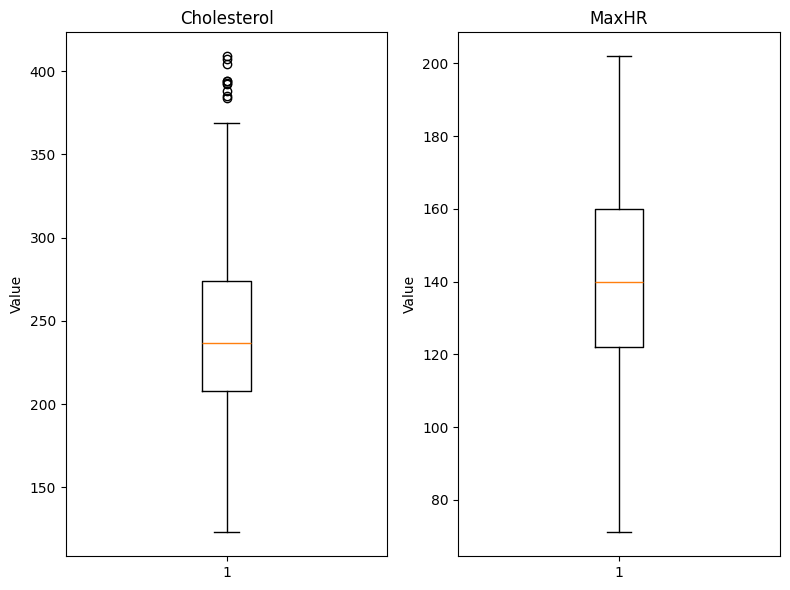

In [ ]:
col_plot = df_drop_outliers[['Cholesterol','MaxHR']]

fig,axes = plt.subplots(1 , len(col_plot.columns) , figsize=(8,6))

for ax , col in zip(axes,col_plot):
    ax.boxplot(df_drop_outliers[col])
    ax.set_title(col)
    ax.set_ylabel('Value')
    
plt.tight_layout()
plt.show()

In [ ]:
df_drop_outliers = df_drop_outliers[df_drop_outliers['MaxHR'] >= Q1_MaxHR - (1.5 * IQR_MaxHR)]

In [ ]:
## กำหนด MaxHR ที่ HeartDisease = 0 ให้ได้

df_drop_outliers[df_drop_outliers['MaxHR'] < Q1_MaxHR - (1.5*IQR_MaxHR)]['HeartDisease'].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
df_drop_outliers[df_drop_outliers['MaxHR'] < Q1_MaxHR - (1.5*IQR_MaxHR)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
